# TSA Complaints Analysis

## Project Overview

This project analyzes Transportation Security Administration (TSA) complaint data across U.S. airports. The analysis examines complaint activity over time, complaint subcategories, monthly complaint distributions at major airports, geographic complaint patterns, complaint-category rankings, and airport distribution by region.

Four TSA-related datasets are combined to create six visualizations that highlight important complaint and airport patterns.


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 2. Set Project Paths

In [2]:
CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project folders ready:")
print(" - data/")
print(" - figures/")


Project folders ready:
 - data/
 - figures/


## 3. Load the Datasets

In [3]:
airport_df = pd.read_csv(
    DATA_DIR / "complaints-by-airport.csv"
)

category_df = pd.read_csv(
    DATA_DIR / "complaints-by-category.csv"
)

subcategory_df = pd.read_csv(
    DATA_DIR / "complaints-by-subcategory.csv"
)

iata_df = pd.read_csv(
    DATA_DIR / "iata-icao.csv"
)

print("All four datasets loaded successfully.")

print("\nComplaints by airport:")
display(airport_df.head())

print("\nComplaints by category:")
display(category_df.head())

print("\nComplaints by subcategory:")
display(subcategory_df.head())

print("\nAirport reference data:")
display(iata_df.head())


All four datasets loaded successfully.

Complaints by airport:


,pdf_report_date,airport,year_month,count
0,2019-02,ABE,2015-01,0
1,2019-02,ABE,2015-02,0
2,2019-02,ABE,2015-03,0
3,2019-02,ABE,2015-04,0
4,2019-02,ABE,2015-05,2



Complaints by category:


,pdf_report_date,airport,category,year_month,count,clean_cat,clean_cat_status
0,2019-02,ABE,Hazardous Materials Safety,2015-01,0,Hazardous Materials Safety,original
1,2019-02,ABE,Mishandling of Passenger Property,2015-01,0,Mishandling of Passenger Property,original
2,2019-02,ABE,Hazardous Materials Safety,2015-02,0,Hazardous Materials Safety,original
3,2019-02,ABE,Mishandling of Passenger Property,2015-02,0,Mishandling of Passenger Property,original
4,2019-02,ABE,Hazardous Materials Safety,2015-03,0,Hazardous Materials Safety,original



Complaints by subcategory:


,pdf_report_date,airport,category,subcategory,year_month,count,clean_cat,clean_subcat,clean_cat_status,clean_subcat_status,is_category_prefix_removed
0,2019-02,ABE,Hazardous Materials Safety,General,2015-01,0,Hazardous Materials Safety,General,original,original,False
1,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-01,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False
2,2019-02,ABE,Hazardous Materials Safety,General,2015-02,0,Hazardous Materials Safety,General,original,original,False
3,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-02,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False
4,2019-02,ABE,Hazardous Materials Safety,General,2015-03,0,Hazardous Materials Safety,General,original,original,False



Airport reference data:


,country_code,region_name,iata,icao,airport,latitude,longitude
0,AE,Abu Zaby,AAN,OMAL,Al Ain International Airport,24.2617,55.6092
1,AE,Abu Zaby,AUH,OMAA,Abu Dhabi International Airport,24.4330,54.6511
2,AE,Abu Zaby,AYM,NaN,Yas Island Seaplane Base,24.4670,54.6103
3,AE,Abu Zaby,AZI,OMAD,Al Bateen Executive Airport,24.4283,54.4581
4,AE,Abu Zaby,DHF,OMAM,Al Dhafra Air Base,24.2482,54.5477


## 4. Clean and Prepare the Data

In [4]:
# Standardize column names across all datasets.
for df in [
    airport_df,
    category_df,
    subcategory_df,
    iata_df
]:
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

# Convert date columns.
airport_df["year_month"] = pd.to_datetime(
    airport_df["year_month"]
)

category_df["year_month"] = pd.to_datetime(
    category_df["year_month"]
)

subcategory_df["year_month"] = pd.to_datetime(
    subcategory_df["year_month"]
)

# Create year and month fields.
for df in [
    airport_df,
    category_df,
    subcategory_df
]:
    df["year"] = df["year_month"].dt.year
    df["month"] = df["year_month"].dt.month
    df["month_name"] = df["year_month"].dt.month_name()

# Remove rows with missing or blank airport codes.
for df in [
    airport_df,
    category_df,
    subcategory_df
]:
    df.dropna(
        subset=["airport"],
        inplace=True
    )

    df.drop(
        df[
            df["airport"]
            .astype(str)
            .str.strip()
            .eq("")
        ].index,
        inplace=True
    )

    df["airport"] = (
        df["airport"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Standardize airport codes in the reference dataset.
iata_df["iata"] = (
    iata_df["iata"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Replace missing complaint counts with zero.
for df in [
    airport_df,
    category_df,
    subcategory_df
]:
    df["count"] = df["count"].fillna(0)

print("Data cleaning completed successfully.")


Data cleaning completed successfully.


In [5]:
print("Complaints by airport after cleaning:")
display(airport_df.head())

print("\nComplaints by category after cleaning:")
display(category_df.head())

print("\nComplaints by subcategory after cleaning:")
display(subcategory_df.head())

print("\nAirport reference data after cleaning:")
display(iata_df.head())


Complaints by airport after cleaning:


,pdf_report_date,airport,year_month,count,year,month,month_name
0,2019-02,ABE,2015-01-01,0,2015,1,January
1,2019-02,ABE,2015-02-01,0,2015,2,February
2,2019-02,ABE,2015-03-01,0,2015,3,March
3,2019-02,ABE,2015-04-01,0,2015,4,April
4,2019-02,ABE,2015-05-01,2,2015,5,May



Complaints by category after cleaning:


,pdf_report_date,airport,category,year_month,count,clean_cat,clean_cat_status,year,month,month_name
0,2019-02,ABE,Hazardous Materials Safety,2015-01-01,0,Hazardous Materials Safety,original,2015,1,January
1,2019-02,ABE,Mishandling of Passenger Property,2015-01-01,0,Mishandling of Passenger Property,original,2015,1,January
2,2019-02,ABE,Hazardous Materials Safety,2015-02-01,0,Hazardous Materials Safety,original,2015,2,February
3,2019-02,ABE,Mishandling of Passenger Property,2015-02-01,0,Mishandling of Passenger Property,original,2015,2,February
4,2019-02,ABE,Hazardous Materials Safety,2015-03-01,0,Hazardous Materials Safety,original,2015,3,March



Complaints by subcategory after cleaning:


,pdf_report_date,airport,category,subcategory,year_month,count,clean_cat,clean_subcat,clean_cat_status,clean_subcat_status,is_category_prefix_removed,year,month,month_name
0,2019-02,ABE,Hazardous Materials Safety,General,2015-01-01,0,Hazardous Materials Safety,General,original,original,False,2015,1,January
1,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-01-01,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False,2015,1,January
2,2019-02,ABE,Hazardous Materials Safety,General,2015-02-01,0,Hazardous Materials Safety,General,original,original,False,2015,2,February
3,2019-02,ABE,Mishandling of Passenger Property,Damaged/Missing Items--Checked Baggage,2015-02-01,0,Mishandling of Passenger Property,*Damaged/Missing Items--Checked Baggage,original,original,False,2015,2,February
4,2019-02,ABE,Hazardous Materials Safety,General,2015-03-01,0,Hazardous Materials Safety,General,original,original,False,2015,3,March



Airport reference data after cleaning:


,country_code,region_name,iata,icao,airport,latitude,longitude
0,AE,Abu Zaby,AAN,OMAL,Al Ain International Airport,24.2617,55.6092
1,AE,Abu Zaby,AUH,OMAA,Abu Dhabi International Airport,24.4330,54.6511
2,AE,Abu Zaby,AYM,NaN,Yas Island Seaplane Base,24.4670,54.6103
3,AE,Abu Zaby,AZI,OMAD,Al Bateen Executive Airport,24.4283,54.4581
4,AE,Abu Zaby,DHF,OMAM,Al Dhafra Air Base,24.2482,54.5477


## 5. Complaint Activity by Month and Year

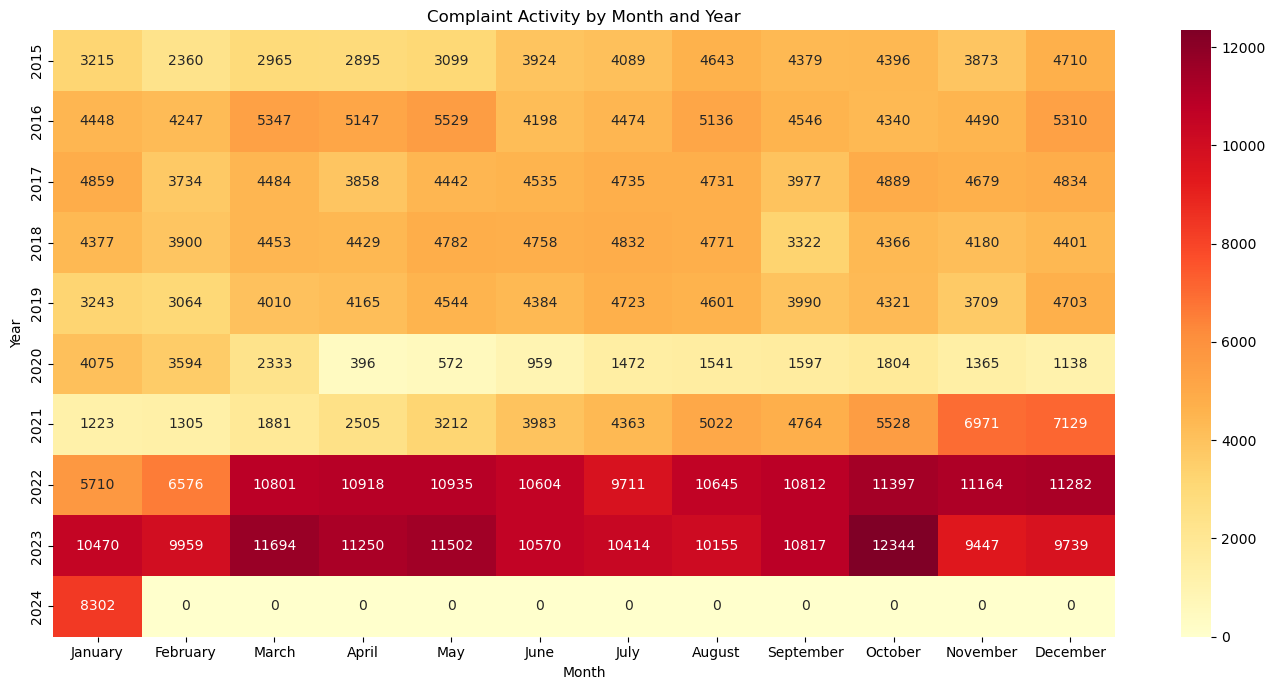

Saved: figures/complaint_activity_by_month_and_year_heatmap.jpg


In [6]:
heatmap_data = (
    airport_df
    .groupby(["year", "month_name"])["count"]
    .sum()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot_table(
    index="year",
    columns="month_name",
    values="count",
    fill_value=0
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

heatmap_pivot = heatmap_pivot[month_order]

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Complaint Activity by Month and Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()

save_path = (
    FIGURES_DIR
    / "complaint_activity_by_month_and_year_heatmap.jpg"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/"
    "complaint_activity_by_month_and_year_heatmap.jpg"
)


### Observation

- The number of TSA complaints was fairly stable between 2015 and 2019, fell dramatically in 2020, and grew significantly beginning in 2022.
- The greatest number of complaints was recorded between 2022 and 2023, reflecting a substantial increase in passenger grievances during the post-pandemic period.


## 6. Complaint Trends by Subcategory Over Time

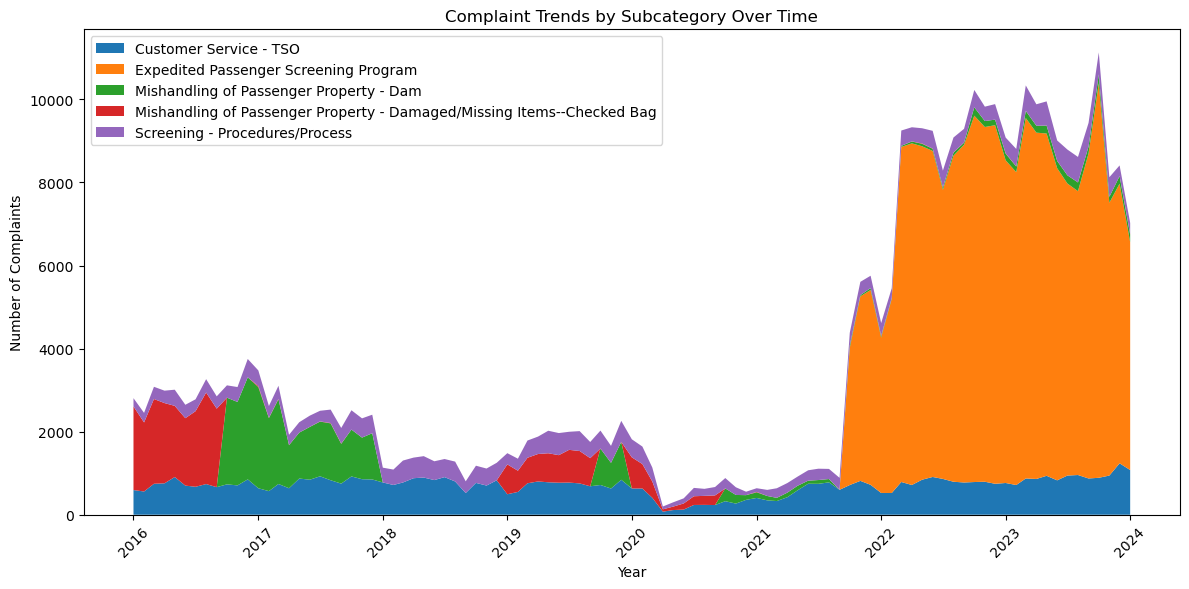

Saved: figures/complaint_trends_by_subcategory_over_time.jpg


In [7]:
top_subcats = (
    subcategory_df
    .groupby("subcategory")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

area_data = subcategory_df[
    subcategory_df["subcategory"].isin(top_subcats)
]

area_pivot = area_data.pivot_table(
    index="year_month",
    columns="subcategory",
    values="count",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 6))

plt.stackplot(
    area_pivot.index,
    area_pivot.T,
    labels=area_pivot.columns
)

plt.title("Complaint Trends by Subcategory Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()

save_path = (
    FIGURES_DIR
    / "complaint_trends_by_subcategory_over_time.jpg"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/"
    "complaint_trends_by_subcategory_over_time.jpg"
)


### Observation

- Expedited Passenger Screening Program was the top complaint subcategory from 2021 onward and contributed the largest share of complaints.
- The other major complaint subcategories remained relatively stable, indicating that the increase in complaints was concentrated heavily in screening-program issues.


## 7. Monthly Complaint Distribution Across Top Airports

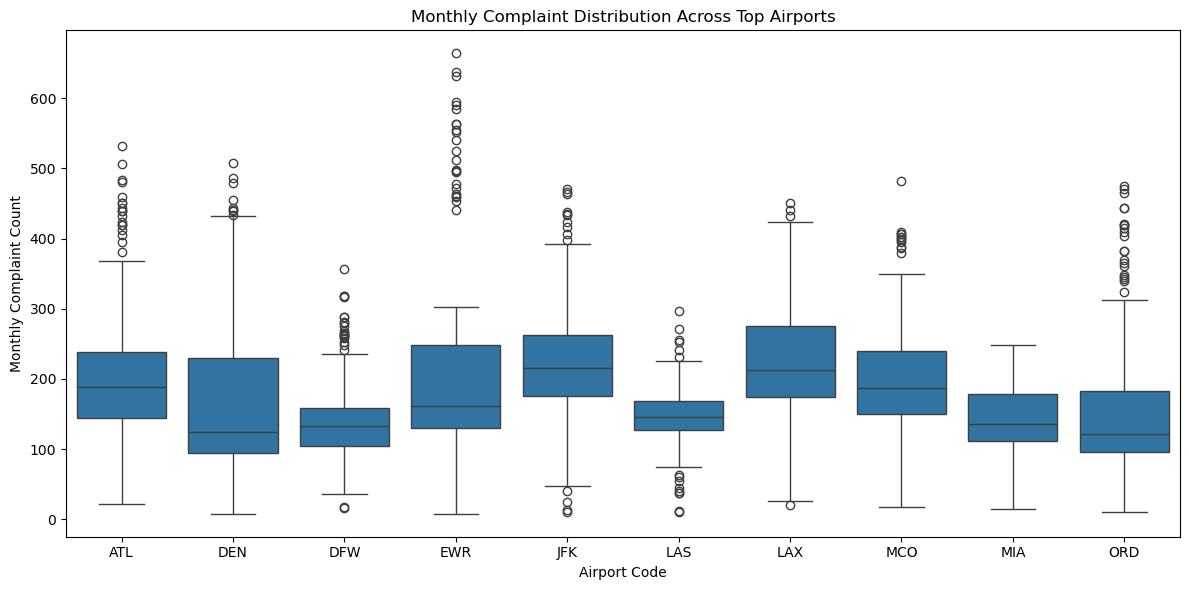

Saved: figures/monthly_complaint_distribution_top_airports.jpg


In [8]:
top_airports = (
    airport_df
    .groupby("airport")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

boxplot_data = airport_df[
    airport_df["airport"].isin(top_airports)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=boxplot_data,
    x="airport",
    y="count"
)

plt.title(
    "Monthly Complaint Distribution Across Top Airports"
)
plt.xlabel("Airport Code")
plt.ylabel("Monthly Complaint Count")
plt.tight_layout()

save_path = (
    FIGURES_DIR
    / "monthly_complaint_distribution_top_airports.jpg"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/"
    "monthly_complaint_distribution_top_airports.jpg"
)


### Observation

- JFK and LAX airports have higher median complaint counts and greater variability than several other major airports.
- The presence of multiple outliers suggests periods when complaints increase sharply, potentially during disruptions or peak travel periods.


## 8. Spatial Distribution of TSA Complaints by Airport

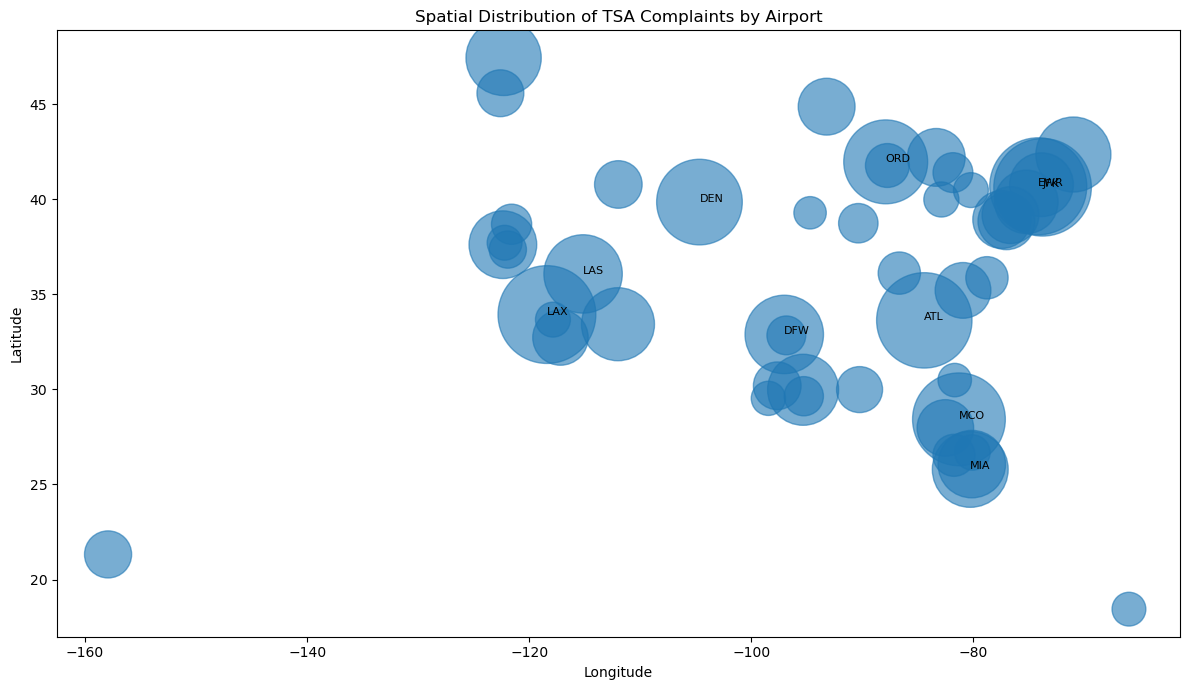

Saved: figures/spatial_distribution_of_tsa_complaints.jpg


In [9]:
airport_map_df = airport_df.merge(
    iata_df,
    left_on="airport",
    right_on="iata",
    how="left"
)

airport_map_df = airport_map_df.dropna(
    subset=["latitude", "longitude"]
)

map_data = (
    airport_map_df
    .groupby(
        [
            "airport_x",
            "latitude",
            "longitude"
        ]
    )["count"]
    .sum()
    .reset_index()
    .sort_values(
        "count",
        ascending=False
    )
    .head(50)
)

plt.figure(figsize=(12, 7))

plt.scatter(
    map_data["longitude"],
    map_data["latitude"],
    s=map_data["count"] / 5,
    alpha=0.6
)

for _, row in map_data.head(10).iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        row["airport_x"],
        fontsize=8
    )

plt.title(
    "Spatial Distribution of TSA Complaints by Airport"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

save_path = (
    FIGURES_DIR
    / "spatial_distribution_of_tsa_complaints.jpg"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/"
    "spatial_distribution_of_tsa_complaints.jpg"
)


### Observation

- Complaints are concentrated at major airports located in metropolitan areas, especially in the Northeast, Southeast, Texas, and California.
- Higher complaint totals appear at airports that likely handle larger passenger volumes.


## 9. Complaint Category Ranking

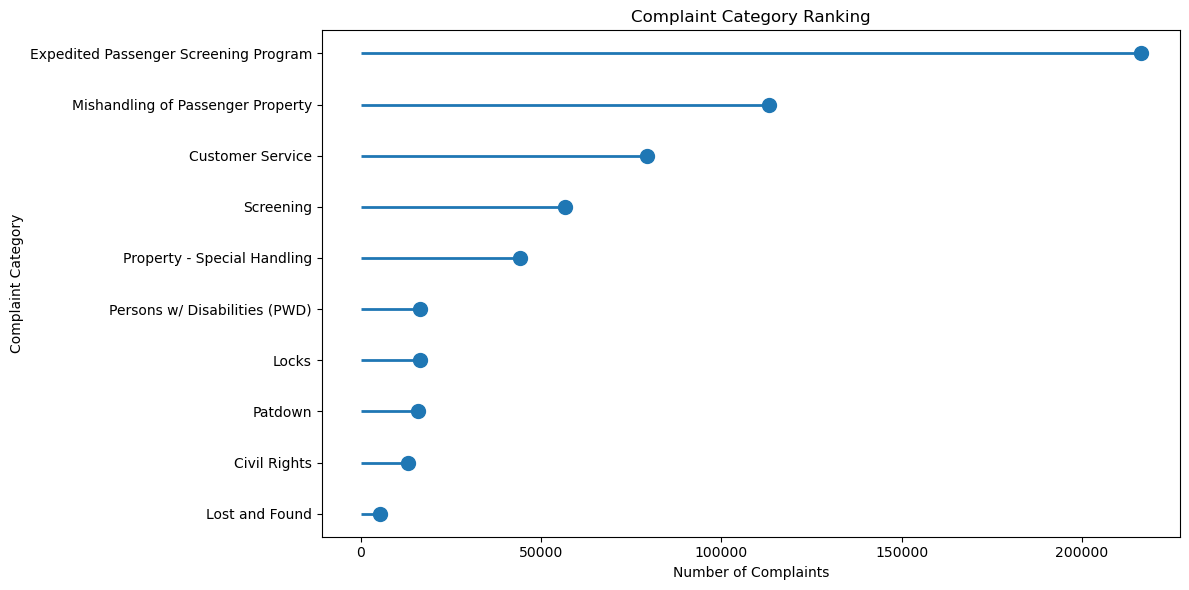

Saved: figures/complaint_category_ranking.jpg


In [10]:
top_categories = (
    category_df
    .groupby("category")["count"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.hlines(
    y=top_categories["category"],
    xmin=0,
    xmax=top_categories["count"],
    linewidth=2
)

plt.scatter(
    top_categories["count"],
    top_categories["category"],
    s=100
)

plt.title("Complaint Category Ranking")
plt.xlabel("Number of Complaints")
plt.ylabel("Complaint Category")
plt.tight_layout()

save_path = (
    FIGURES_DIR
    / "complaint_category_ranking.jpg"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/"
    "complaint_category_ranking.jpg"
)


### Observation

- Complaints related to the Expedited Passenger Screening Program dominate the dataset and significantly exceed all other complaint categories.
- Categories such as Civil Rights, Lost and Found, Patdown, and Locks contribute a relatively small share of total complaints.


## 10. Airport Distribution by Region

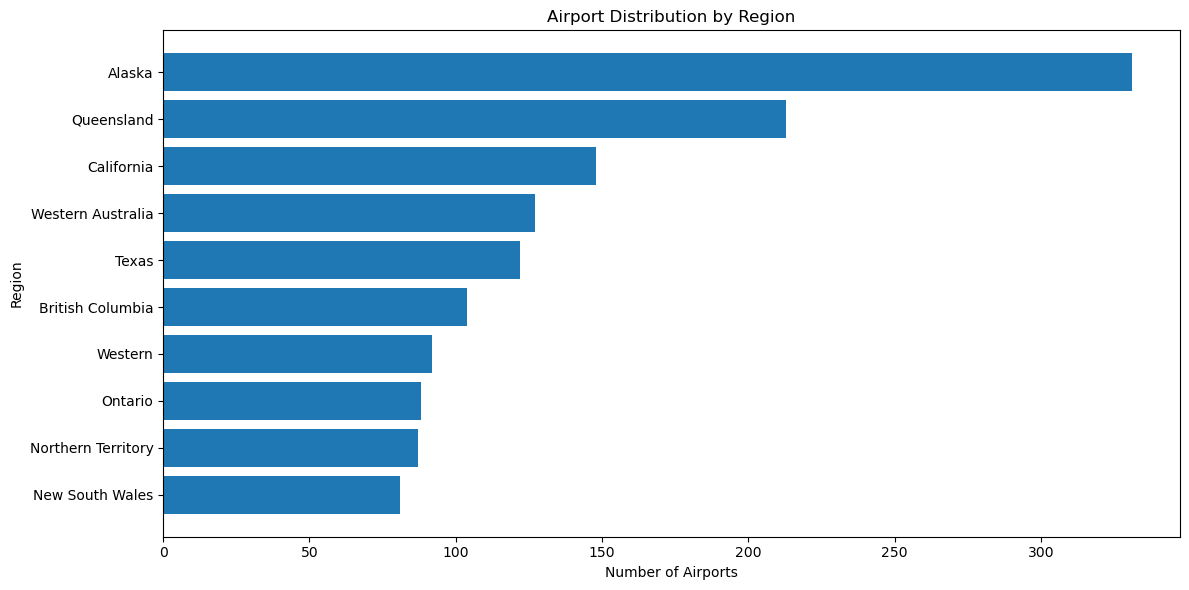

Saved: figures/airport_distribution_by_region.jpg


In [11]:
region_counts = (
    iata_df
    .groupby("region_name")["iata"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="airport_count")
)

plt.figure(figsize=(12, 6))

plt.barh(
    region_counts["region_name"],
    region_counts["airport_count"]
)

plt.title("Airport Distribution by Region")
plt.xlabel("Number of Airports")
plt.ylabel("Region")
plt.gca().invert_yaxis()
plt.tight_layout()

save_path = (
    FIGURES_DIR
    / "airport_distribution_by_region.jpg"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: figures/"
    "airport_distribution_by_region.jpg"
)


### Observation

- Alaska contains the most airports in the dataset, significantly outnumbering other regions.
- Airport facilities are unevenly distributed across regions, with a small number of regions containing a large share of airports.


## 11. Saved Project Outputs

In [12]:
print("Figures saved:")

for file in sorted(FIGURES_DIR.glob("*.jpg")):
    print(" -", f"figures/{file.name}")


Figures saved:
 - figures/airport_distribution_by_region.jpg
 - figures/complaint_activity_by_month_and_year_heatmap.jpg
 - figures/complaint_category_ranking.jpg
 - figures/complaint_trends_by_subcategory_over_time.jpg
 - figures/monthly_complaint_distribution_top_airports.jpg
 - figures/spatial_distribution_of_tsa_complaints.jpg


## Conclusion

This project uses TSA complaint and airport-reference data to examine complaint patterns across time, complaint types, airports, and regions.

The visualizations show a substantial decline in complaints during 2020 followed by strong growth beginning in 2022. Screening-program complaints make up a major share of the overall complaint activity, while large airports such as JFK and LAX show relatively high complaint levels and greater variability.

The analysis also highlights geographic concentration at major metropolitan airports and differences in airport distribution across regions.
